# 02 - Exploratory Data Analysis
This notebook assumes the dataset has already been cleaned in `01_data_preprocessing.ipynb`. The objective is to answer business questions, not perform data cleaning.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

df = pd.read_csv("../data/cleaned/superstore_cleaned.csv")
df.head()
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
df["Ship_Date"] = pd.to_datetime(df["Ship_Date"])


## Executive KPIs

In [15]:
total_revenue = df["Sales"].sum()
total_profit = df["Profit"].sum()
orders = df["Order_ID"].nunique()
customers = df["Customer_ID"].nunique()
products = df["Product_ID"].nunique()
aov = total_revenue / orders

print(f"Revenue: ${total_revenue:,.2f}")
print(f"Profit: ${total_profit:,.2f}")
print(f"Orders: {orders}")
print(f"Customers: {customers}")
print(f"Products: {products}")
print(f"Average Order Value: ${aov:,.2f}")

Revenue: $12,642,905.00
Profit: $1,467,457.29
Orders: 25035
Customers: 4873
Products: 10292
Average Order Value: $505.01


## Monthly Sales & Profit Trends

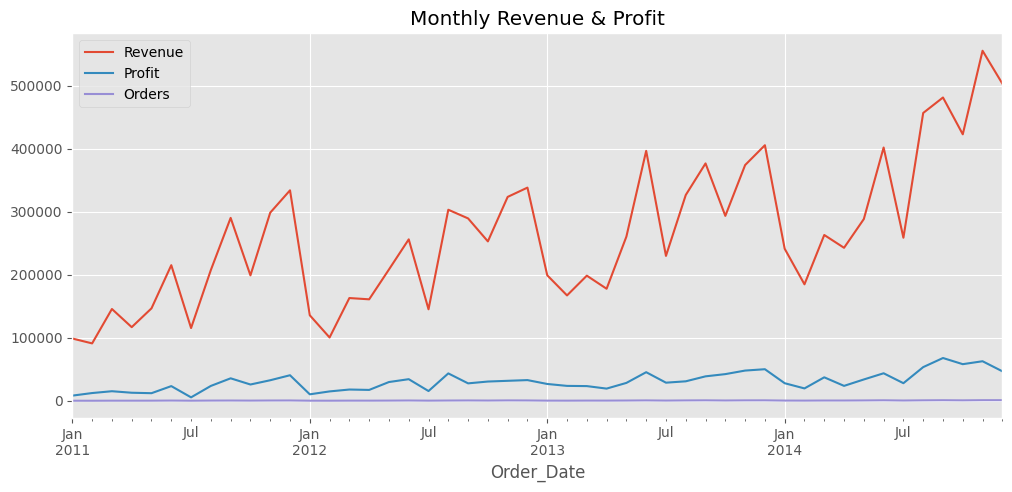

In [30]:
monthly = df.groupby(pd.Grouper(key="Order_Date", freq="ME")).agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order_ID","nunique")
)
monthly.plot(figsize=(12,5), title="Monthly Revenue & Profit")
plt.show()

## Category Performance

,Revenue,Profit,Quantity
Category,,,
Technology,4744691,663778.73318,35176
Furniture,4110884,285204.72380,34954
Office Supplies,3787330,518473.83430,108182


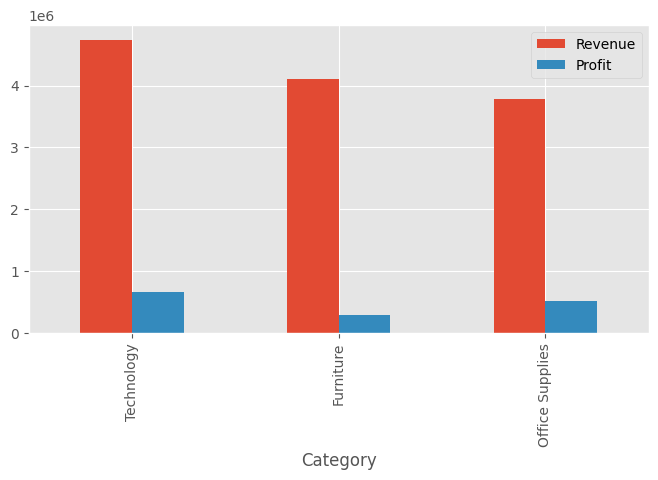

In [31]:
cat = df.groupby("Category").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Quantity=("Quantity","sum")
).sort_values("Revenue", ascending=False)
display(cat)
cat[["Revenue","Profit"]].plot(kind="bar", figsize=(8,4))
plt.show()

## Sub-Category Performance

In [32]:
sub = df.groupby("Sub_Category").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum")
).sort_values("Revenue", ascending=False)
display(sub)

,Revenue,Profit
Sub_Category,,
Phones,1706874,216717.00580
Copiers,1509439,258567.54818
Chairs,1501682,140396.26750
Bookcases,1466559,161924.41950
Storage,1127124,108461.48980
Appliances,1011081,141680.58940
Machines,779071,58867.87300
Tables,757034,-64083.38870
Accessories,749307,129626.30620


## Top Customers

In [33]:
top_customers = df.groupby("Customer_Name").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Orders=("Order_ID","nunique")
).sort_values("Revenue", ascending=False)
display(top_customers.head(20))

,Revenue,Profit,Orders
Customer_Name,,,
Tom Ashbrook,40489,6311.97910,30
Tamara Chand,37453,8672.89890,36
Greg Tran,35552,5214.13118,34
Christopher Conant,35187,5603.33370,39
Sean Miller,35170,-409.70634,28
Bart Watters,32315,3595.88590,45
Natalie Fritzler,31778,1542.82110,43
Fred Hopkins,30404,4609.29112,39
Jane Waco,30288,6265.84570,40


## Product Performance

In [34]:
products = df.groupby("Product_Name").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum"),
    Quantity=("Quantity","sum")
).sort_values("Revenue", ascending=False)
display(products.head(20))
display(products.tail(20))

,Revenue,Profit,Quantity
Product_Name,,,
"Apple Smart Phone, Full Size",86936,5921.5786,171
"Cisco Smart Phone, Full Size",76441,17238.5206,139
"Motorola Smart Phone, Full Size",73159,17027.1130,134
"Nokia Smart Phone, Full Size",71904,9938.1955,147
Canon imageCLASS 2200 Advanced Copier,61600,25199.9280,20
"Hon Executive Leather Armchair, Adjustable",58200,5997.2541,169
"Office Star Executive Leather Armchair, Adjustable",50667,4710.9840,141
"Harbour Creations Executive Leather Armchair, Adjustable",50120,10427.3260,142
"Samsung Smart Phone, Cordless",48654,-198.0900,108


,Revenue,Profit,Quantity
Product_Name,,,
Acco Economy Flexible Poly Round Ring Binder,11,-5.7420,6
Maxell 4.7GB DVD+R 5/Pack,11,4.6035,13
Letter Slitter,10,0.3024,4
Storex Flexible Poly Binders with Double Pockets,10,-2.0064,9
Hoover Replacement Belt for Commercial Guardsman Heavy-Duty Upright Vacuum,10,0.4440,6
PNY Rapid USB Car Charger - Black,10,-2.0774,2
Newell 337,10,1.1808,4
Newell 342,10,2.8536,3
Avery 484,9,3.3408,4


## Regional Analysis

,Revenue,Profit
Region,,
Central,2822399,311403.98164
South,1600960,140355.76618
North,1248192,194597.95252
Oceania,1100207,120089.11200
Southeast Asia,884438,17852.32900
North Asia,848349,165578.42100
EMEA,806184,43897.97100
Africa,783776,88871.63100
Central Asia,752839,132480.18700


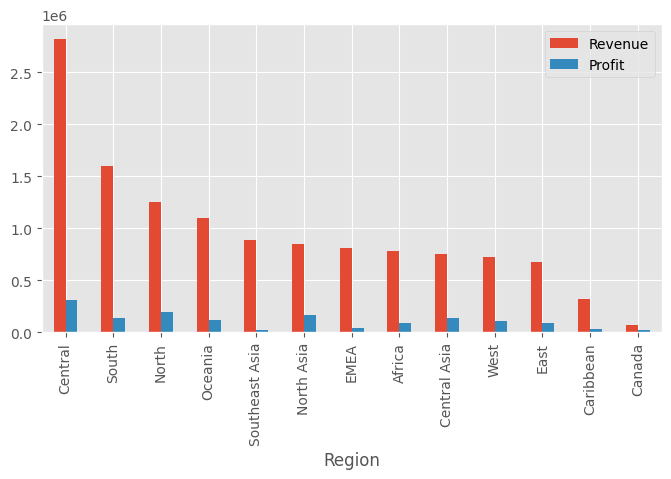

In [35]:
region = df.groupby("Region").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum")
).sort_values("Revenue", ascending=False)
display(region)
region.plot(kind="bar", figsize=(8,4))
plt.show()

## State Analysis

In [36]:
states = df.groupby("State").agg(
    Revenue=("Sales","sum"),
    Profit=("Profit","sum")
).sort_values("Revenue", ascending=False)
display(states.head(15))

,Revenue,Profit
State,,
England,485166,99907.73100
California,457731,76381.38710
Ile-de-France,317818,44055.92400
New York,310914,74038.54860
New South Wales,270509,43695.98400
Queensland,238311,21608.75400
North Rhine-Westphalia,216458,42347.87100
Texas,170187,-25729.35630
San Salvador,153648,35883.37700


## Discount Impact

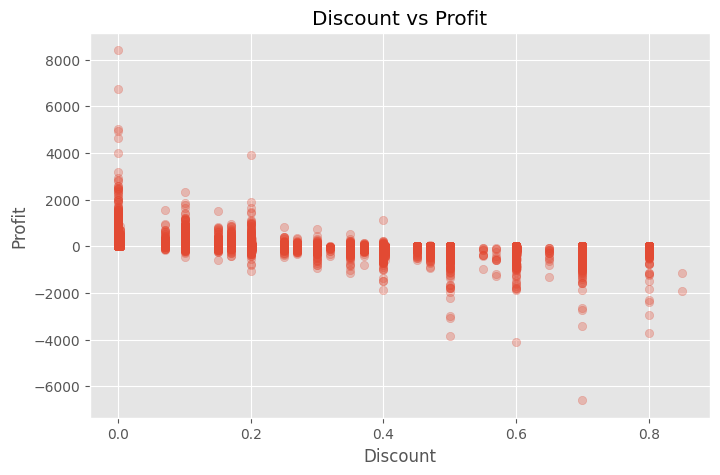

,Sales,Profit
Discount,,
0.000,241.053949,61.039514
0.002,567.017354,125.762649
0.070,810.800000,140.990022
0.100,388.303343,63.683426
0.150,565.687616,50.602409
0.170,336.604082,38.317107
0.200,240.867347,23.552594
0.202,395.439024,-14.518847
0.250,444.762626,4.043371


In [41]:
plt.figure(figsize=(8,5))
plt.scatter(df["Discount"], df["Profit"], alpha=0.3)
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Discount vs Profit")
plt.show()

display(df.groupby("Discount")[["Sales","Profit"]].mean())

## Shipping Analysis

In [38]:
ship = df.groupby("Ship_Mode").agg(
    Revenue=("Sales","sum"),
    ShippingCost=("Shipping_Cost","mean")
)
display(ship)

,Revenue,ShippingCost
Ship_Mode,,
First Class,1831067,41.052970
Same Day,667202,42.937325
Second Class,2565747,30.469666
Standard Class,7578889,19.971654


## Correlation

,Discount,Profit,Quantity,Row_ID,Sales,Shipping_Cost,Year,weeknum,Shipping_Days,Order_Year,Order_Month,Order_Quarter,Profit_Margin_%
Discount,1.000000,-0.316490,-0.019875,0.087594,-0.086728,-0.079055,-0.005894,-0.000217,-0.001507,-0.005894,0.000027,0.000466,-0.846371
Profit,-0.316490,1.000000,0.104365,-0.019037,0.484923,0.354441,0.002626,-0.000182,0.001745,0.002626,0.000140,0.000487,0.357290
Quantity,-0.019875,0.104365,1.000000,-0.173483,0.313580,0.272649,-0.005049,0.020839,0.004347,-0.005049,0.020611,0.022496,0.050446
Row_ID,0.087594,-0.019037,-0.173483,1.000000,-0.043888,-0.039076,-0.000921,-0.028776,-0.018082,-0.000921,-0.028695,-0.032242,-0.114130
Sales,-0.086728,0.484923,0.313580,-0.043888,1.000000,0.768075,-0.002902,0.001947,-0.004661,-0.002902,0.001813,0.002371,0.074585
Shipping_Cost,-0.079055,0.354441,0.272649,-0.039076,0.768075,1.000000,-0.003137,0.005347,-0.142823,-0.003137,0.004929,0.005970,0.067668
Year,-0.005894,0.002626,-0.005049,-0.000921,-0.002902,-0.003137,1.000000,-0.019627,-0.003427,1.000000,-0.014193,-0.011695,0.006108
weeknum,-0.000217,-0.000182,0.020839,-0.028776,0.001947,0.005347,-0.019627,1.000000,0.005241,-0.019627,0.995987,0.966328,0.012068
Shipping_Days,-0.001507,0.001745,0.004347,-0.018082,-0.004661,-0.142823,-0.003427,0.005241,1.000000,-0.003427,0.005268,0.005829,0.000108
Order_Year,-0.005894,0.002626,-0.005049,-0.000921,-0.002902,-0.003137,1.000000,-0.019627,-0.003427,1.000000,-0.014193,-0.011695,0.006108


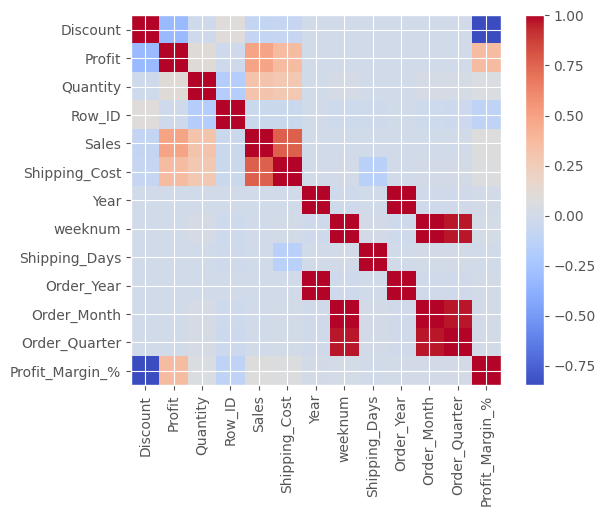

In [39]:
corr = df.select_dtypes(include=np.number).corr()
display(corr)
plt.imshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

## Executive Summary

- Best performing category: Technology
- Lowest profit category: Furniture
- Regions needing attention: Texas, National Capital, Pennsylvania
- Effect of discounts: Discounts have very little effect on sales but reduce overall profit
- High-value products: Apple Smart Phone, Cisco Smart Phone, Motorola Smart Phone
- Shipping observations: Most users opt for standard or second class delivery, and then first class delivery. The least being same day delivery which is almost 30% of first class delivery
